<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 3.2: Estimating the noise PSD and whitening/band-passing data

This tutorial will present how to do estimate the noise PSD from data, how to simulate noise, and how to visualize whitened and band-passed data.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/03_Signal_Processing/Tuto_3.2_Noise_PSD.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).


## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
! pip install -q 'gwpy==3.0.14' 'cryptography==43.0.0' 'PyCBC==2.10.0'

## Initialization

In [3]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [4]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [5]:
import gwosc
print(gwosc.__version__)

0.8.2


In [6]:
import gwpy
print(gwpy.__version__)

3.0.14


In [7]:
import pycbc
print(pycbc.__version__)

2.10.0


## A few basics

In this tutorial, we will talk about the [Power Spectral Density (PSD)](https://en.wikipedia.org/wiki/Spectral_density), characterizing the noise as a stochastic process.

We recall that one definition for the PSD of stationary noise $S_n(f)$ is (from a data stretch of length $T$)
$$ S_{n}(f) = \lim_{T \rightarrow +\infty} \frac{2}{T} \langle \left| \tilde{n}_{T}(f) \right|^{2} \rangle$$
meaning that the PSD measures the spectral shape of the noise time series. Another useful definition is
$$ \frac{1}{2} S_{n}(f) = \int d\tau \, e^{-2 i \pi f \tau} C_n(\tau)$$
where $C_{n}(\tau)$ is the noise autocorrelation function (which depends only on lag in the case of stationary noise)
$$ C_{n}(\tau) = \langle n(t) n(t+\tau)\rangle$$

The stationarity is what gives us the following crucial property: the FD noise in different bins is independent. In the continuous-limit notations for infinitely long signals,
$$\langle\tilde{n}(f) \tilde{n}^*(f')\rangle = \frac{1}{2} S_n(f) \delta(f - f')$$

Incorporating the fact that we always work with a finite duration $T$ and discrete frequencies, and only then take the limit of $T \rightarrow \infty$,
$$ \frac{2}{T}\langle \tilde{n}_T(f_k) \tilde{n}^{\ast}_T(f_l) \rangle \underset{T\to \infty}{\to} S_{n}(f_k) \delta_{kl} $$

## An analytical model

We start with a toy model example of what the PSD looks like for an instrument like LIGO, Virgo or KAGRA. At high frequencies, shot noise dominates. At intermediate frequencies, thermal noise creates a noise floor. At low frequencies, there are limiting noise walls due to both seismic noise and Newtonian noise; however today's instruments are limited by a set of technical 'control' hard-to-model noises.

In [8]:
# -- Define an array or frequencies
freqs = np.geomspace(10, 2048, 2000)

# -- Make a cartoon model of LIGO noise
controls = 4e-12*(1/freqs**8)
thermal = 3e-23*(1/freqs**0.5)
shot = 3.5e-24*(np.sqrt(1+(freqs/500)**2))
cartoon_asd = np.sqrt(controls**2+shot**2+thermal**2)

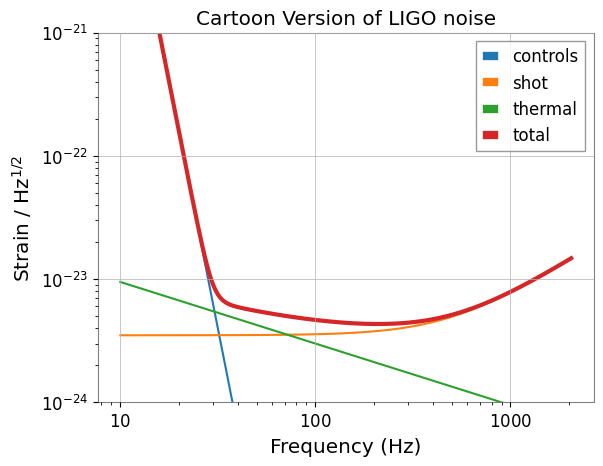

In [9]:
# -- Plot the cartoon model
plt.loglog(freqs, controls, label='controls')
plt.loglog(freqs, shot, label='shot')
plt.loglog(freqs, thermal, label='thermal')
plt.loglog(freqs, cartoon_asd, linewidth=3, label='total')
plt.ylim(1e-24, 1e-21)
plt.title('Cartoon Version of LIGO noise')
plt.ylabel('Strain / Hz$^{1/2}$')
plt.xlabel('Frequency (Hz)')
plt.legend()

## Estimating the power spectral density

In the tutorial on Fourier transforms, we saw that the Fourier spectrum has a similar-looking spectral shape. However, the Fourier transform of data is affected by random fluctuations of the noise random process. To estimate the PSD, we can reduce these fluctuations by averaging many estimates of the signal FFT, in order to approach an ensemble average $\langle \rangle$ (since the FFT components are complex quantities, what we really want to average are their squared moduli). This comes at a price, since we need to cut the data stretch in different pieces to do the average. Since the resolution in frequency depends on the length of the data according to $df = 1/T$, we have a trade-off between ensemble averaging power on one side and frequency resolution of the PSD on the other side.

A standard way to do this PSD estimation is [Welch's estimation method](https://en.wikipedia.org/wiki/Welch%27s_method). It is also convenient to express the result not as a power but as an amplitude, taking the square root of the above expression. The resulting quantity takes the name Amplitude Spectral Density (ASD) of the signal.

We will first download data from GWOSC, around the event GW190412 (an unequal-mass binary black hole coalescence, see the corresponding [paper](https://arxiv.org/pdf/2004.08342))

In [10]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

Downloading a segment of data of length [-16s, +16s] around the event with GWpy (this may take a couple of minutes depending on your network connection).

In [11]:
gps = event_gps('GW190412')

segment = (int(gps)-16, int(gps)+16)
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)

Fetched 1 URLs from gwosc.org for [1239082246 .. 1239082278))
Reading data... [Done]


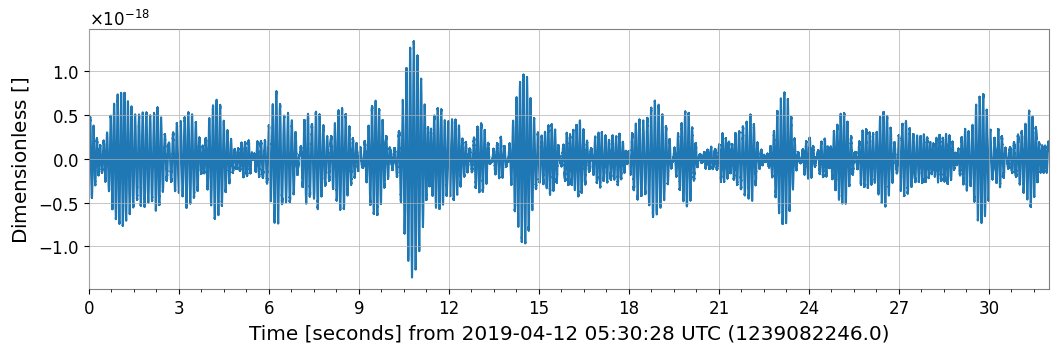

In [12]:
ldata.plot();

Let's look at the duration and sampling rate of our data:

In [13]:
T = ldata.duration.value
dt = ldata.dt.value
fs = 1./dt
T, dt, fs

(np.float64(32.0), np.float64(0.000244140625), np.float64(4096.0))

The following evaluates the PSD using Welch's method. `nperseg` determines the size of the data segments that are used to compute a spectrum, the spectra being then averaged (this is a simplified description; in practice overlapping segments are used).

Note: the PSD we compute estimates the noise; but the data segment that we consider also contains a gravitational wave signal! However, the data segment contains a lot of data before and after the signal anyway, and the signal is both weak and short enough so that its contribution here is negligible. Future instruments such as Einstein Telescope (ET), Cosmic Explorer (CE) and Laser Interferometer Space Antenna (LISA) might be signal-dominated instead of noise-dominated.

In [14]:
freqs_welch, psd_welch = scipy.signal.welch(ldata.value, fs,  window='hann', nperseg=4096)

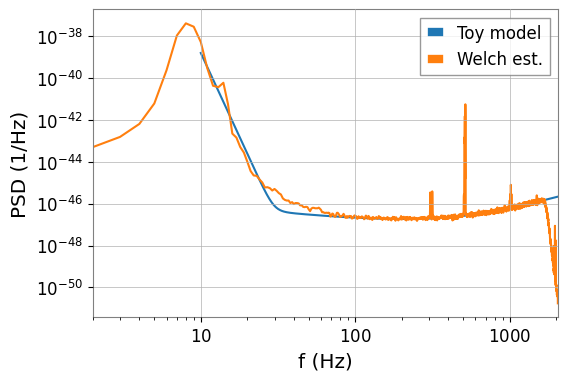

In [15]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs, cartoon_asd**2, label='Toy model')
ax.loglog(freqs_welch, psd_welch, label='Welch est.')
ax.set_xlim(2., 2048.)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'PSD (1/Hz)')
ax.legend()

Let's customize this figure plotting the ASD instead of the PSD, by zooming in the frequency range of interest, that is, above the seismic noise shoulder at 10 Hz and below the cut-off at the Nyquist frequency, and resizing the y-axis accordingly.

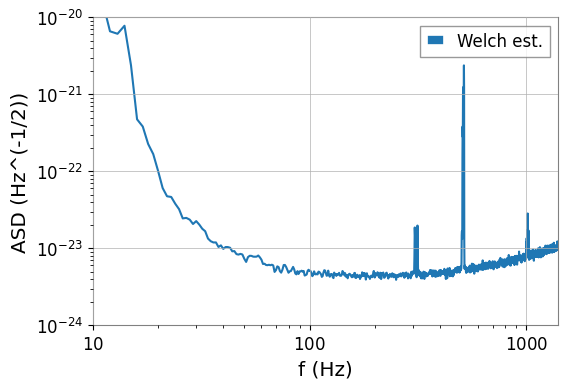

In [16]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_welch[1:], np.sqrt(psd_welch[1:]), label='Welch est.')
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()

The ASD is a standard tool used to study the frequency-domain sensitivity of a gravitational-wave detector.
For the LIGO-Livingston data we loaded, we can see large spikes at certain frequencies (called spectral lines), including

- ~300 Hz
- ~500 Hz
- ~1000 Hz

The [O3 spectral lines](https://gwosc.org/O3/o3aspeclines/) page on GWOSC describes a number of these spectral features for O3, with some of them being forced upon us, and some being deliberately introduced to help with interferometer control.

## Effect of segment length and duration

We can explore the options in the function `scipy.signal.welch`. Notably, we said that there is a trade-off regarding the length of segments: longer segments give a better frequency resolution, but give less averaging power. We try with different values of `nperseg`. The default overlap between segments is `nperseg//2`. More information can be found on the [documentation page](https://docs.scipy.org/doc/scipy-1.13.1/reference/generated/scipy.signal.welch.html) for `scipy.signal.welch`.

In [17]:
freqs_welch_shortseg, psd_welch_shortseg = scipy.signal.welch(ldata.value, fs,  window='hann', nperseg=1024)
freqs_welch_longseg, psd_welch_longseg = scipy.signal.welch(ldata.value, fs,  window='hann', nperseg=8192)

In [18]:
freqs_welch_shortseg.shape, freqs_welch_longseg.shape

((513,), (4097,))

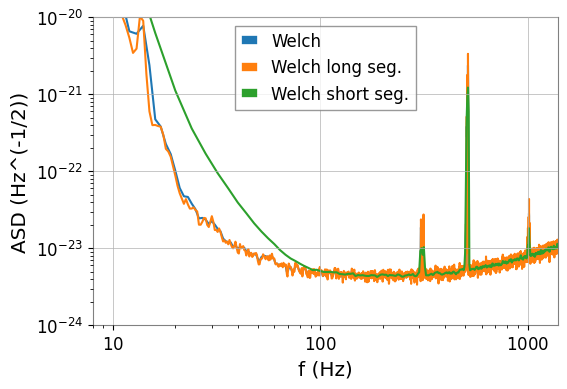

In [19]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_welch, np.sqrt(psd_welch), label='Welch')
ax.loglog(freqs_welch_longseg, np.sqrt(psd_welch_longseg), label='Welch long seg.')
ax.loglog(freqs_welch_shortseg, np.sqrt(psd_welch_shortseg), label='Welch short seg.')
ax.set_xlim(8., 1400.)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()

Let's focus on the frequencies between 250Hz and 400Hz.

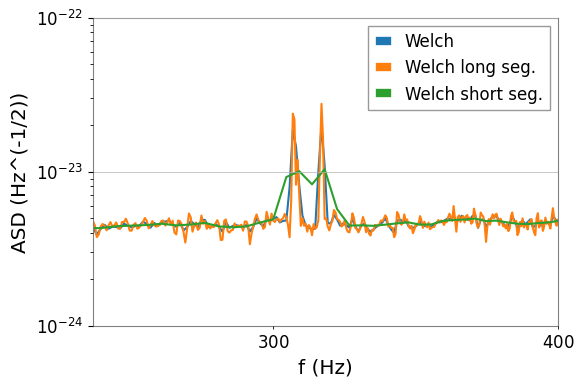

In [20]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_welch, np.sqrt(psd_welch), label='Welch')
ax.loglog(freqs_welch_longseg, np.sqrt(psd_welch_longseg), label='Welch long seg.')
ax.loglog(freqs_welch_shortseg, np.sqrt(psd_welch_shortseg), label='Welch short seg.')
ax.set_xlim(250., 400.)
ax.set_ylim(1e-24, 1e-22)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()

Let us explore the effect of increasing the duration in seconds of the data used. We take a longer segment [-512s,+512s]; thanks to the longer duration, we have now more statistical power for the ensemble average. The result is smoother, as it depends less on statistical fluctuations. Now we can see some more features, including a small bump at about 60 Hz, the frequency of the electric mains in the US.

The price to pay in that case is that, the longer the data segment, the more it is susceptible to have non-stationary features.

In [21]:
gps = event_gps('GW190412')

segment = (int(gps)-512, int(gps)+512)
ldata2 = TimeSeries.fetch_open_data('L1', *segment, verbose=True)

Fetched 1 URLs from gwosc.org for [1239081750 .. 1239082774))
Reading data... [Done]


In [22]:
freqs_welch_longdata, psd_welch_longdata = scipy.signal.welch(ldata2.value, fs,  window='hann', nperseg=4096)

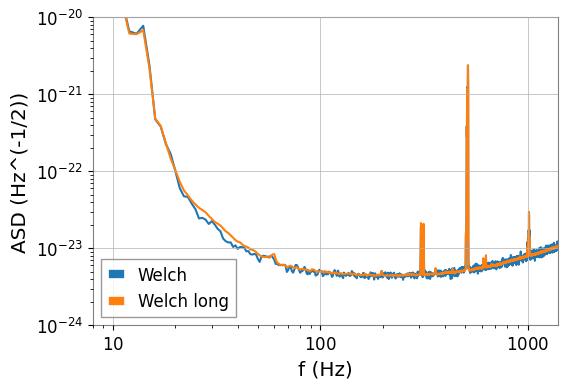

In [23]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_welch, np.sqrt(psd_welch), label='Welch')
ax.loglog(freqs_welch_longdata, np.sqrt(psd_welch_longdata), label='Welch long')
ax.set_xlim(8., 1400.)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()

## Going further

There exists other methods to estimate the PSD.

As an alternative to Welch's method, one could have combined the various FFT estimates calculating their median, which can be a more robust statistic than the mean implemented in Welch's method with respect to spurious fluctuations of the signal level.
This is called the median method.

We will briefly experiment with this in the next section.
For a review, see, e.g. [Chatziioannou et al. (2019)](https://ui.adsabs.harvard.edu/abs/2019PhRvD.100j4004C/abstract).

## GWpy and pycbc interface

The **GWpy** library provides the [`asd()`](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/?highlight=asd#gwpy.timeseries.TimeSeries.asd) method of `TimeSeries`, which uses the above technique to combine FFTs estimated on overlapping, windowed chunks of data.

The `asd()` in GWpy accepts both `'median'` or `'welch'` as possible methods to estmate the ASD of a signal. Take a look also at the [other optional parameters](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.asd).

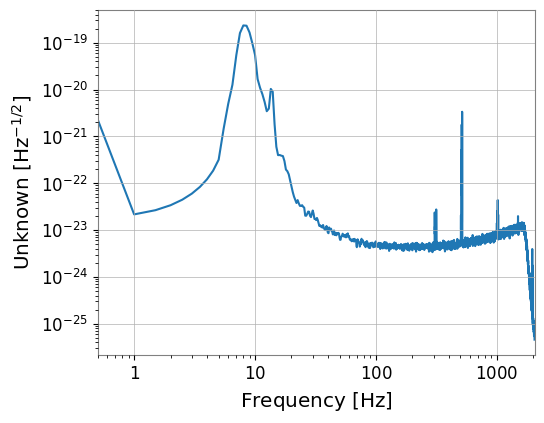

In [24]:
asd_gwpy_welch = ldata.asd(fftlength=2, method="welch")
asd_gwpy_median = ldata.asd(fftlength=2, method="median")
plot = asd_gwpy_welch.plot()
plot.show(warn=False)

The PyCBC library provides the [`psd()`](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.timeseries.TimeSeries.psd) method of `TimeSeries`, which implements the Welch method via `pycbc.psd.welch`.

In [25]:
from pycbc.frame.gwosc import read_strain_gwosc

ldata_pycbc = read_strain_gwosc('L1', *segment)

In [26]:
# If the cell above is slow, comment it and use the following lines

#from gwosc.locate import get_urls
#from pycbc.frame import read_frame
#import os
#URL = get_urls("L1", *segment, format='gwf')[1]
#file = os.path.basename(URL)
#print(URL, file)
#if not os.path.exists(file):
#    ! wget $URL
#ldata_pycbc = read_frame(file, "L1:GWOSC-4KHZ_R1_STRAIN", start_time=segment[0], end_time=segment[1])

In [27]:
fftlength = 2.
psd_pycbc = ldata_pycbc.psd(fftlength)

Let's check that these different PSD estimation methods agree with each other, with only minor differences:

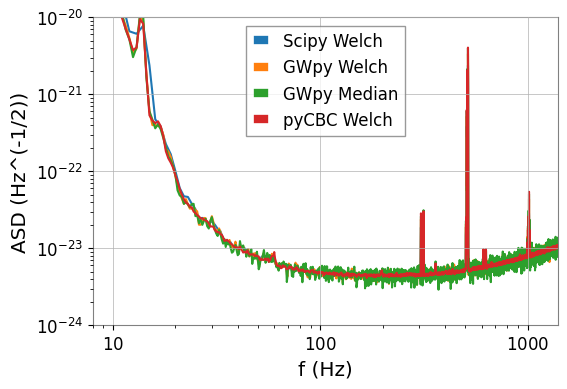

In [28]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_welch[1:], np.sqrt(psd_welch[1:]), label='Scipy Welch')
ax.loglog(asd_gwpy_welch.frequencies.value, asd_gwpy_welch.value, label='GWpy Welch')
ax.loglog(asd_gwpy_welch.frequencies.value, asd_gwpy_median.value, label='GWpy Median')
ax.loglog(psd_pycbc.get_sample_frequencies().data, np.sqrt(psd_pycbc.data), label='pyCBC Welch')
ax.set_xlim(8., 1400.)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()

## PSDs of three detectors

For comparison, we can load the LIGO-Hanford and Virgo data and plot them as well:

In [29]:
# get Livingston data if not done before
# ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")

# get Hanford data
hdata2 = TimeSeries.fetch_open_data('H1', int(gps)-512, int(gps)+512, cache=True)
hasd2 = hdata2.asd(fftlength=4, method="median")

# get Virgo data
vdata2 = TimeSeries.fetch_open_data('V1', int(gps)-512, int(gps)+512, cache=True)
vasd2 = vdata2.asd(fftlength=4, method="median")

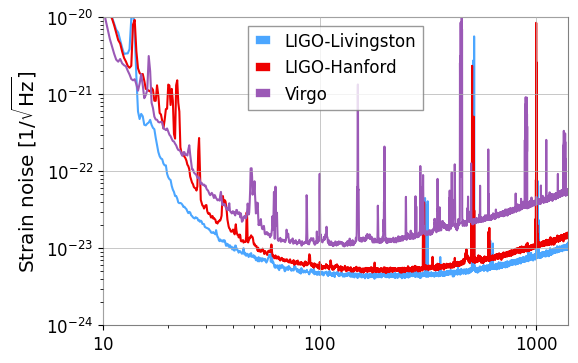

In [30]:
fig, ax = plt.subplots(1,1, figsize=[6,4])

# and plot using standard colours
ax.loglog(lasd2, label='LIGO-Livingston', color='gwpy:ligo-livingston')
ax.loglog(hasd2, label='LIGO-Hanford', color='gwpy:ligo-hanford')
ax.loglog(vasd2, label='Virgo', color='gwpy:virgo')

ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
ax.set_ylabel(r'Strain noise [$1/\sqrt{\mathrm{Hz}}$]')
ax.legend()

Now we can see clearly the relative sensitivity of each detectors of LIGO and Virgo, the common features between those, like the general trend at low and high frequency, and those unique to each observatory.

# Whitening and band-passing real data

## Downloading data and evaluating the PSD

In [31]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

We will now talk about whitening and band-passing of the data, which allows to both visualize the relevant information content of the data and to build some intuition about the significance of the signals. We will first download data from GWOSC, around the event GW150914 (the famous first direct detection of a gravitational wave signal, see the corresponding [paper](https://arxiv.org/pdf/1602.03837))

Downloading a segment of data of length [-4s, +4s] around the event with GWpy (this may take a couple of minutes depending on your network connection).

In [32]:
gps = event_gps('GW150914')
segment = (int(gps)-4, int(gps)+4)
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True)

Fetched 1 URLs from gwosc.org for [1126259458 .. 1126259466))
Reading data... [Done]


Here we repeat previous steps: we compute the Fourier transform of the data, and we estimate the PSD using GWpy tools.

In [33]:
T = hdata.shape[0] * hdata.dt.value
dt = hdata.dt.value
N = hdata.shape[0]
T, N, dt

(np.float64(8.0), 32768, np.float64(0.000244140625))

In [34]:
w = scipy.signal.windows.tukey(hdata.shape[0], 0.1)
hdata_w = w * hdata
hdata_fd = hdata_w.fft() / (2/T)

asd = hdata.asd(fftlength=1., method="welch")

In [35]:
hdata_fd.df.value, 1./T

(np.float64(0.125), np.float64(0.125))

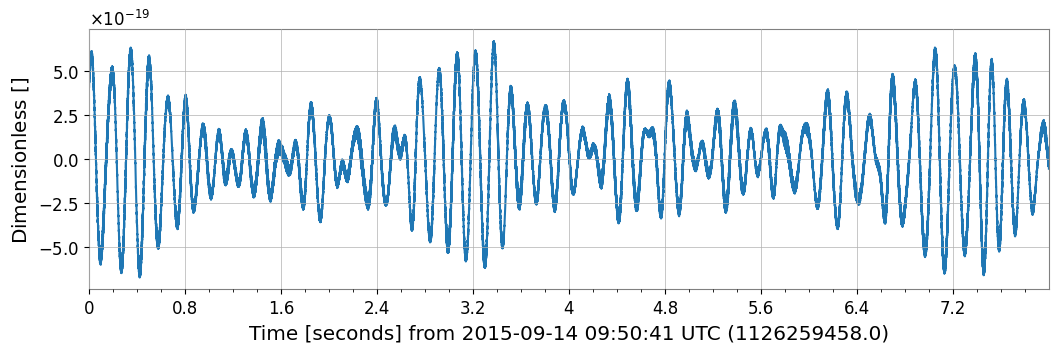

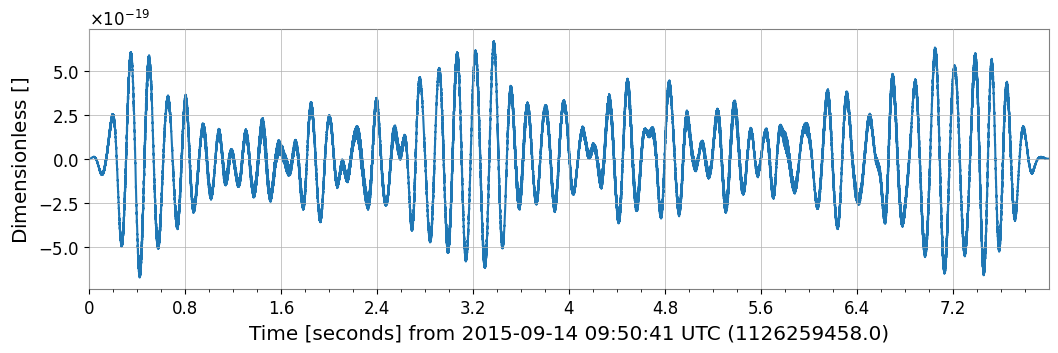

In [36]:
hdata.plot();
hdata_w.plot();

## Correspondence between data and PSD

As a way to link more directly the PSD and the data in the Fourier domain, we recall that for a stationary (circulant, in fact) Gaussian process, its Fourier domain real/imaginary values are all independent Gaussian variables. For FD indices $j=1,\dots,N/2-1$ ($j=0$ and $j=N/2$ are edge cases that we leave aside) and frequency resolution $\Delta f = 1/T$,

$$ \mathrm{Re}(\tilde{n}_j) \sim \mathcal{N}\left(0,\frac{S_n(f_j)}{4 \Delta f}\right) \,, \quad \mathrm{Im}(\tilde{n}_j) \sim \mathcal{N}\left(0,\frac{S_n(f_j)}{4 \Delta f}\right)$$

This tells us in particular that

$$ \langle |\tilde{n}_j|^2 \rangle = \frac{S_n(f_j)}{2 \Delta f} $$

We check this below, with the appropriate factor of $\sqrt{2 \Delta f}$.

(1e-24, 1e-20)

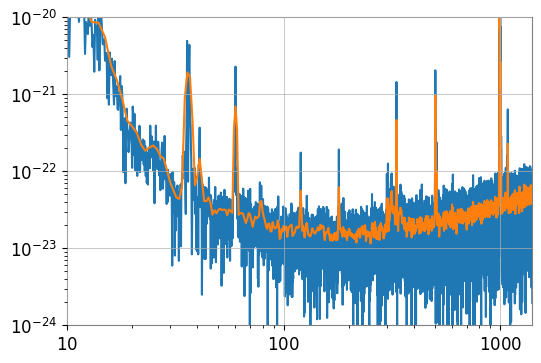

In [37]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(hdata_fd.frequencies.value[1:], np.abs(hdata_fd.value[1:]))
ax.loglog(asd.frequencies.value[1:], asd.value[1:] / np.sqrt(2*hdata_fd.df.value))
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)

## Whitening, band-passing

The above behaviour motivates **whitening** the data, by introducing a Fourier-domain rescaling of the data as

$$ \tilde{d}_j^{\rm w} \equiv \sqrt{\frac{2 \Delta f}{S_n(f_j)}} \tilde{d}_j$$

The new variables will represent **white noise**: all Fourier bins will have the same variance (different normalization conventions might exist).

Another aspect of GW astronomy in general is that our instruments are never sensitive to low or high frequencies. Those two extremes will typically completely dominate the power in our data stream, as shown by the shape of the PSD. This motivates **band-passing** the data, artificially eliminating frequency content that is at lower or higher frequency than the band of interest for the signal we consider. For stationary noise, the noise is statistically independent between Fourier bins, so ignoring a range of frequencies is allowed; we essentially choose to ignore those noisy bins by marginalizing the likelihood over them.  

$$ \tilde{d}_j^{\rm wbp}(f) \equiv \tilde{w}_{\rm bp}(f) \tilde{d}_j^{\rm w}(f)$$

where $\tilde{w}_{\rm bp}(f)$ goes to 0 at low and high frequencies.

In [38]:
# Definitions for the windowing function -- function for vectorial argument
# Similar to the Tukey window: tapering to 0 with a cosine on each end. This interface is flexible, in order to allow for asymmetric tapering width at each end.
def window_tukey(x, xi, xf, deltaxi, deltaxf):
    '''
    Window function based on Tukey, with unequal tapering lengths at the beginning and end.
    Zero outside of [xi,xf], one on [xi+deltaxi, xf-deltaxf], tapering smoothly from 0 to 1 on [xi,xi+deltaxi] and from 1 to 0 on [xf-deltaxf,xf]
    '''
    w = np.zeros(len(x), dtype=float)
    #
    mask = (x <= xi) | (x >= xf)
    w[mask] = 0.
    #
    mask = (xi < x) & (x < xi + deltaxi)
    w[mask] = (1. - np.cos((x[mask] - xi) / deltaxi * np.pi)) / 2
    #
    mask = (xi + deltaxi <= x) & (x <= xf - deltaxf)
    w[mask] = 1.
    #
    mask = (xf - deltaxf < x) & (x < xf)
    w[mask] = (1. + np.cos((x[mask] - xf - deltaxf) / deltaxf * np.pi)) / 2
    #
    return w

Here we choose the band of frequencies to select: we target [20,400]Hz, and we taper to 0 on [10,20]Hz and on [400,500]Hz. Note that we are using some insider knowledge: we know in advance that this particular system is quite massive, and we know that the signal is rapidly falling off after 400Hz. This helps us in killing a lot of power in high frequencies that are not relevant for this GW event, but that would be important for lower-mass systems.

In [39]:
freq = hdata_fd.frequencies.value
df = hdata_fd.df.value

asd_interp = scipy.interpolate.interp1d(asd.frequencies.value, asd.value)

window_bp = window_tukey(freq, 10., 500., 10., 100.)

hdata_wbp = window_bp * hdata_fd.value / (asd_interp(freq) / np.sqrt(2*df))

Text(0.5, 0, 'f (Hz)')

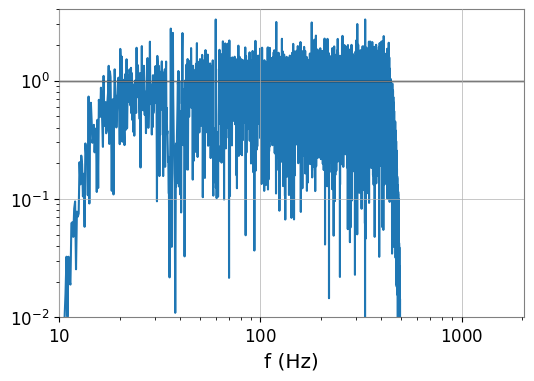

In [40]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freq, np.abs(hdata_wbp))
ax.set_xlim(10, 2048)
ax.set_ylim(1e-2, 4)
ax.axhline(1., c='k', lw=1.)
ax.set_xlabel('f (Hz)')

## Whitened, band-passed signal in the time domain

A property of white noise is that the independence between data points applies both to the Fourier domain and the time domain. This means that the inverse Fourier transform

$$ d^{\rm w} \equiv \mathrm{IFT}[\tilde{d}^{\rm w}] $$

will feature noise that is uniform and independent across time samples. This type of data is easier to interpret visually; 'what you see is what you get'.

In [41]:
hdata_wbp_td = df * np.fft.irfft(hdata_wbp)

times = dt * np.arange(len(hdata_wbp_td))

Text(0, 0.5, 'Whitened band-passed strain')

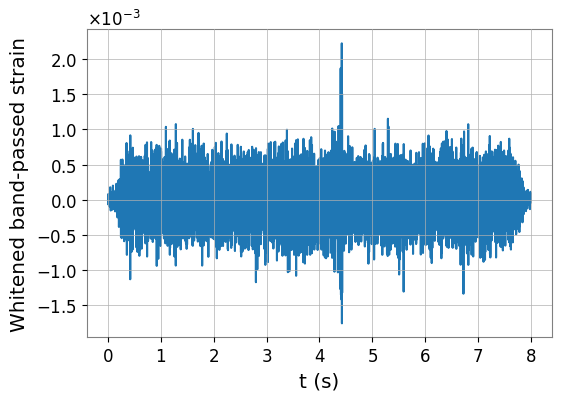

In [42]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(times, hdata_wbp_td)
ax.set_xlabel('t (s)')
ax.set_ylabel('Whitened band-passed strain')

Text(0, 0.5, 'Whitened band-passed strain')

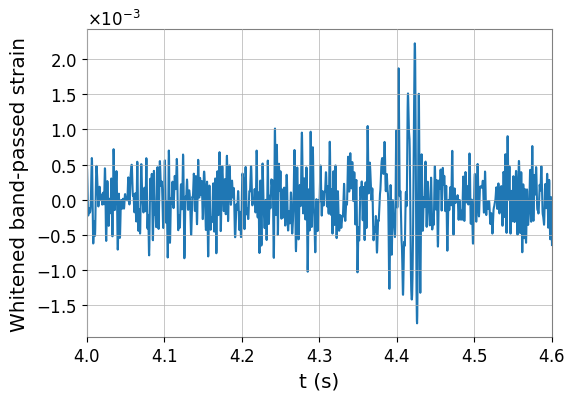

In [43]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(times, hdata_wbp_td)
ax.set_xlim(4, 4.6)
ax.set_xlabel('t (s)')
ax.set_ylabel('Whitened band-passed strain')

## Quiz Questions

### Question 1

Compare the ASD around the time of an O1 event, GW150914, with the ASDs around GW190412 an O3 event, for the same L1 detector. How much did the detector's sensitivity (let's look at the ASD, not PSD) improve over time (say, at a frequency of 100Hz)?

Fetched 1 URLs from gwosc.org for [1126259458 .. 1126259466))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1239082258 .. 1239082266))
Reading data... [Done]


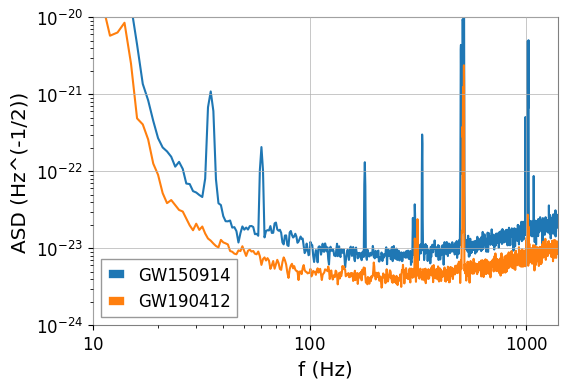

np.float64(1.7384921093855317)

In [46]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries
import numpy as np
import scipy
import matplotlib.pyplot as plt

# Get the data
gps = event_gps('GW150914')
segment = (int(gps)-4, int(gps)+4)
ldata_150414 = TimeSeries.fetch_open_data('L1', *segment, cache=True, verbose=True)

gps = event_gps('GW190412')
segment = (int(gps)-4, int(gps)+4)
ldata_190412 = TimeSeries.fetch_open_data('L1', *segment, cache=True, verbose=True)

# Compute the ASDs and interpolate
asd_150414 = ldata_150414.asd(fftlength=1., method="welch")
asd_150414_interp = scipy.interpolate.interp1d(asd_150414.frequencies, asd_150414.value)
asd_190412 = ldata_190412.asd(fftlength=1., method="welch")
asd_190412_interp = scipy.interpolate.interp1d(asd_190412.frequencies, asd_190412.value)

# Plot them
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(asd_150414.frequencies[1:], asd_150414.value[1:], label='GW150914')
ax.loglog(asd_190412.frequencies[1:], asd_190412.value[1:], label='GW190412')
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'ASD (Hz^(-1/2))')
ax.legend()
plt.show()

# Compute the ratio at 100Hz
asd_150414_interp(100.) / asd_190412_interp(100.)

### Question 2

Is the whitened data really Gaussian ? Verify that $\mathrm{Re}(\tilde{n}_j^{\rm wbp}),\mathrm{Im}(\tilde{n}_j^{\rm wbp})$ are Gaussian distributed by plotting their histogram (make sure to eliminate frequencies that are too low or too high). What is their standard deviation (in the conventions of this notebook)?

Desviación estándar: 0.665


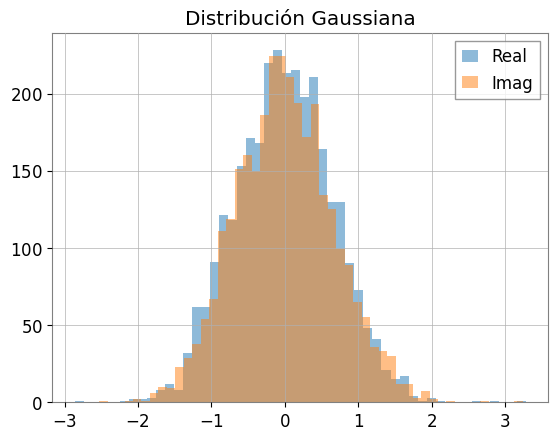

In [45]:
# --- PREGUNTA 2 ---
# Filtrar frecuencias útiles (entre 20 y 400 Hz)
mask = (freq >= 20) & (freq <= 400)
real_parts = np.real(hdata_wbp[mask])
imag_parts = np.imag(hdata_wbp[mask])

std_real = np.std(real_parts)
std_imag = np.std(imag_parts)

print(f"Desviación estándar: {std_real:.3f}")

# Histograma visual
plt.hist(real_parts, bins=50, alpha=0.5, label='Real')
plt.hist(imag_parts, bins=50, alpha=0.5, label='Imag')
plt.legend()
plt.title('Distribución Gaussiana')
plt.show()